In [1]:
import pandas as pd

df = pd.read_csv("car.data.csv")
df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Adding column names in the dataset
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df.columns = col_names
df

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [4]:
# Checking if any columns have null data set or not
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [5]:
df.describe(include='all').T

,count,unique,top,freq
buying,1727,4,high,432
maint,1727,4,high,432
doors,1727,4,3,432
persons,1727,3,4,576
lug_boot,1727,3,med,576
safety,1727,3,med,576
class,1727,4,unacc,1209


In [6]:
# Getting every columns value count of each category
for col in col_names:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [7]:
# Checking duplicate value in each column of dataset
df[df.duplicated()]

,buying,maint,doors,persons,lug_boot,safety,class


In [8]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()
df[['buying']] = oe.fit_transform(df[['buying']])
df[['maint']] = oe.fit_transform(df[['maint']])
df[['doors']] = oe.fit_transform(df[['doors']])
df[['persons']] = oe.fit_transform(df[['persons']])
df[['lug_boot']] = oe.fit_transform(df[['lug_boot']])
df[['safety']] = oe.fit_transform(df[['safety']])
df[['class']] = oe.fit_transform(df[['class']])

In [9]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,3.0,3.0,0.0,0.0,2.0,2.0,2.0
1,3.0,3.0,0.0,0.0,2.0,0.0,2.0
2,3.0,3.0,0.0,0.0,1.0,1.0,2.0
3,3.0,3.0,0.0,0.0,1.0,2.0,2.0
4,3.0,3.0,0.0,0.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...
1722,1.0,1.0,3.0,2.0,1.0,2.0,1.0
1723,1.0,1.0,3.0,2.0,1.0,0.0,3.0
1724,1.0,1.0,3.0,2.0,0.0,1.0,2.0
1725,1.0,1.0,3.0,2.0,0.0,2.0,1.0


In [10]:
X = df.drop(columns=['class'])
y = df['class']

In [11]:
X

,buying,maint,doors,persons,lug_boot,safety
0,3.0,3.0,0.0,0.0,2.0,2.0
1,3.0,3.0,0.0,0.0,2.0,0.0
2,3.0,3.0,0.0,0.0,1.0,1.0
3,3.0,3.0,0.0,0.0,1.0,2.0
4,3.0,3.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...
1722,1.0,1.0,3.0,2.0,1.0,2.0
1723,1.0,1.0,3.0,2.0,1.0,0.0
1724,1.0,1.0,3.0,2.0,0.0,1.0
1725,1.0,1.0,3.0,2.0,0.0,2.0


In [12]:
y

0       2.0
1       2.0
2       2.0
3       2.0
4       2.0
       ... 
1722    1.0
1723    3.0
1724    2.0
1725    1.0
1726    3.0
Name: class, Length: 1727, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,        # number of trees
    bootstrap=True,          # enable bootstrap sampling
    max_features='sqrt',     # random subset of features per split
    random_state=42
)
rf.fit(X_train, y_train)

[0.17975399 0.15638665 0.07189502 0.23225719 0.08463984 0.2750673 ]


In [15]:
y_pred = rf.predict(X_test)
print(y_pred)
print('--' * 20)
y_prob = rf.predict_proba(X_test)
print(y_prob)

[0. 2. 2. 2. 2. 3. 2. 2. 3. 0. 2. 2. 0. 2. 0. 0. 2. 2. 0. 2. 2. 2. 3. 2.
 2. 2. 0. 2. 2. 2. 2. 2. 2. 2. 1. 0. 2. 2. 2. 2. 0. 2. 0. 2. 2. 2. 0. 0.
 2. 0. 0. 0. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2. 2. 2. 0. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 0. 3. 2. 0. 2. 2. 0. 0. 0. 2. 0. 0. 2. 3. 2. 2. 2. 2. 2. 2. 2. 3.
 0. 3. 2. 2. 2. 2. 2. 2. 3. 0. 2. 2. 0. 2. 2. 2. 2. 3. 2. 0. 2. 2. 2. 2.
 2. 0. 2. 2. 2. 2. 2. 2. 1. 2. 2. 2. 3. 2. 2. 2. 2. 0. 0. 2. 2. 2. 2. 2.
 2. 2. 2. 0. 2. 0. 3. 0. 0. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2. 1. 2. 2. 0. 2.
 2. 0. 2. 2. 2. 2. 3. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 3. 2. 0. 2. 0. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 0. 3. 0. 2. 0. 2. 0. 2. 0. 0. 0. 0. 2. 2.
 2. 2. 2. 2. 1. 0. 2. 2. 2. 2. 2. 2. 1. 2. 2. 2. 0. 0. 2. 2. 1. 2. 2. 2.
 2. 2. 2. 0. 0. 2. 2. 2. 0. 2. 2. 2. 0. 0. 0. 2. 2. 0. 0. 2. 2. 2. 2. 2.
 3. 2. 2. 2. 2. 0. 2. 0. 2. 2. 2. 3. 2. 2. 2. 1. 3. 2. 3. 2. 2. 1. 1. 0.
 2. 2. 0. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2. 0. 0. 2. 0.

Confusion Matrix:
 [[105   0   9   2]
 [  4  14   0   3]
 [  0   0 358   0]
 [  1   0   0  23]]
Accuracy: 0.9633911368015414
F1 Score (macro): 0.9003512828337363
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.91      0.93       116
         1.0       1.00      0.67      0.80        21
         2.0       0.98      1.00      0.99       358
         3.0       0.82      0.96      0.88        24

    accuracy                           0.96       519
   macro avg       0.94      0.88      0.90       519
weighted avg       0.96      0.96      0.96       519



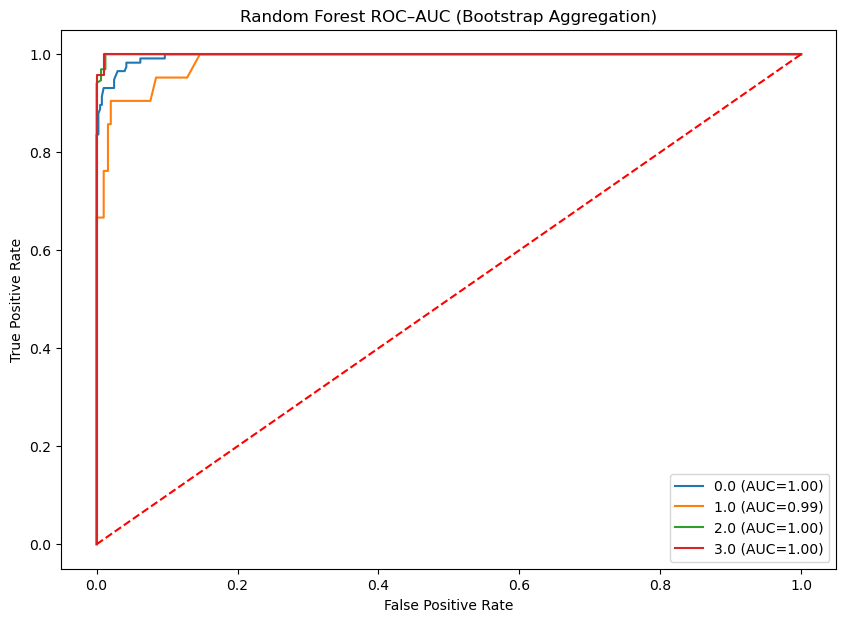

In [16]:
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, f1_score,roc_curve, auc)

# 6. Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 7. ROC–AUC (multiclass One-vs-Rest)
plt.figure(figsize=(10,7))
for i, cls in enumerate(rf.classes_):
    fpr, tpr, _ = roc_curve(y_test == cls, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC–AUC (Bootstrap Aggregation)')
plt.legend(loc="lower right")
plt.show()

In [17]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


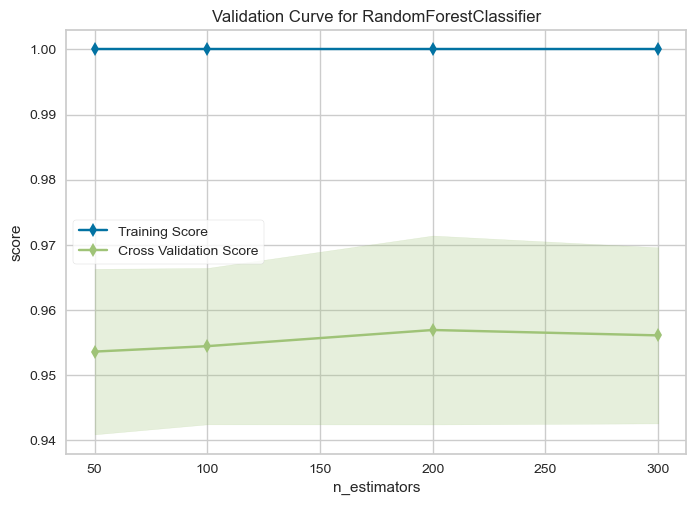

<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='n_estimators', ylabel='score'>

In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from yellowbrick.model_selection import ValidationCurve

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=200,        # number of trees
    bootstrap=True,          # enable bootstrap sampling
    max_features='sqrt',     # random subset of features per split
    random_state=42
)

# Validation Curve visualization
viz = ValidationCurve(
    rf,
    param_name="n_estimators",       # parameter to vary
    param_range=[50, 100, 200, 300], # values to test
    cv=5,
    scoring="accuracy"
)

viz.fit(X_train, y_train)
viz.show()

Accuracy: 0.7927117841930904
Classification Report:
               precision    recall  f1-score   support

          No       0.81      0.93      0.87      1539
         Yes       0.70      0.41      0.52       574

    accuracy                           0.79      2113
   macro avg       0.76      0.67      0.69      2113
weighted avg       0.78      0.79      0.77      2113



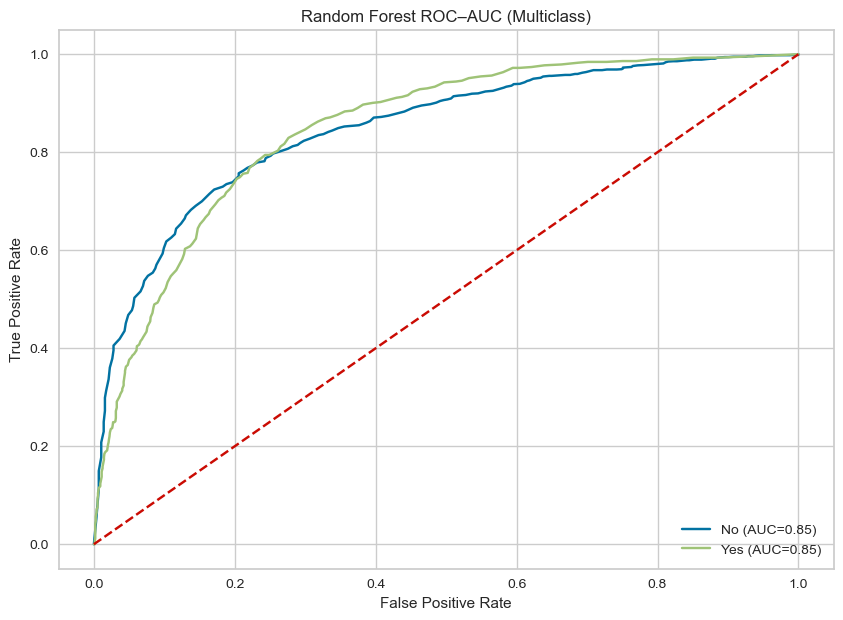

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# 1. Load dataset
df = pd.read_csv("Customer_Churn.csv")

# 2. Features and target
X = df.drop(columns=['Churn'])              # predictors
y = df['Churn'].astype('category')          # target is categorical

# 3. Encoding categorical features
X = pd.get_dummies(X, drop_first=True)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)
rf.fit(X_train_scaled, y_train)

# 7. Predictions
y_pred = rf.predict(X_test_scaled)
y_prob = rf.predict_proba(X_test_scaled)

# 8. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# 9. ROC–AUC (multiclass One-vs-Rest)
plt.figure(figsize=(10,7))
for i, cls in enumerate(rf.classes_):
    fpr, tpr, _ = roc_curve(y_test == cls, y_prob[:, i])
    roc_auc = roc_auc_score(y_test == cls, y_prob[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC–AUC (Multiclass)')
plt.legend(loc="lower right")
plt.show()